## Non-linear regression with feedforward networks

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt

In [2]:
key = jr.key(42)
#key_x, key_W1, key_b1, key_W2, key_b2 = jr.split(key, 5)
key_x, key_W1, key_b1, key_W2, key_b2, key_W3, key_b3 = jr.split(key, 7)

### Data Generation

Synthetic data from the function:

$$y = 2 \sin(3x) - 3 \cos(7x) $$

In [3]:
def f(x):
    return 2*jnp.sin(3*x)  - 3*jnp.cos(7*x)

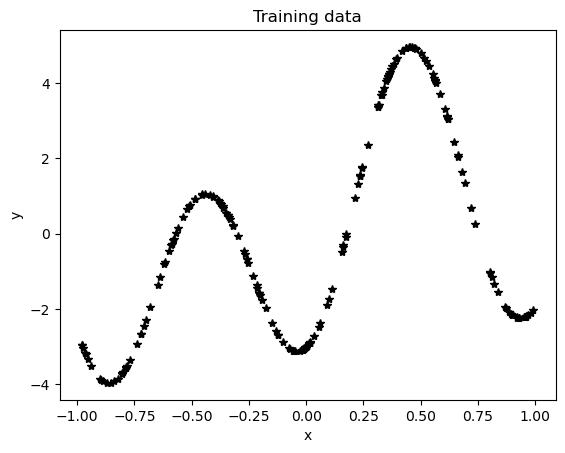

In [4]:
a = -1 # lower limit x
b = 1 # higher limit x
n_samples = 200 # data point
sigma_e = 0.1 # noise std
x_train = a + jr.uniform(key_x, shape=(n_samples, 1))*(b - a);
x_train = x_train.reshape(-1, 1)
y_train = f(x_train)

plt.plot(x_train, y_train, "*k")
plt.title("Training data")
plt.xlabel("x")
plt.ylabel("y");

Always good to check data types and shapes. Saves like 80% of debugging time!

In [5]:
x_train.shape, y_train.shape

((200, 1), (200, 1))

In [6]:
x_train.dtype, y_train.dtype

(dtype('float32'), dtype('float32'))

### Feedforward Neural Network Model Definition

Define the feedforward neural network with one hidden layer:

  $$y = W_2 \tanh (W_1 x + b_1) + b_2 $$

The parameters to be tuned are:

  $$p = \mathrm{vec}(W_1, b_1, W_2, b_2)$$
  $$ W_1 \in \mathbb{R}^{n_h \times n_x}, b_1 \in \mathbb{R}^{n_h}, 
W_2 \in \mathbb{R}^{n_y \times n_h}, b_2 \in \mathbb{R}^{n_y}.$$

In [7]:
# Initialize all parameters and organize them in a dictionary

nx = 1; ny = 1; nh = 16
params = {
  "W1": jr.normal(key_W1, shape=(nh, nx)),
  "b1": jr.normal(key_b1, shape=(nh,)),
  "W2": jr.normal(key_W2, shape=(ny, nh)),
  "b2": jr.normal(key_b2, shape=(ny,)),
}

params

{'W1': Array([[ 0.60576403],
        [ 0.7990441 ],
        [-0.908927  ],
        [-0.63525754],
        [-1.2226585 ],
        [-0.83226097],
        [-0.47417238],
        [-1.2504351 ],
        [-0.17678244],
        [-0.04917514],
        [-0.41177532],
        [-0.39363015],
        [ 1.3116323 ],
        [ 0.21555556],
        [ 0.41164538],
        [-0.28955024]], dtype=float32),
 'b1': Array([ 0.4323065 ,  0.5872638 , -1.1416743 , -0.37379906, -0.19910173,
        -1.7271094 , -1.8330271 , -0.46168378, -0.03195509, -1.7773895 ,
         1.4154723 ,  0.15855731,  1.0224432 , -0.27967322, -0.86966294,
        -0.9404852 ], dtype=float32),
 'W2': Array([[-0.2818947 , -1.367489  , -1.6350379 ,  0.30999872, -0.3844943 ,
          0.20303132,  0.1672151 , -0.87490034,  0.06019142, -0.49940696,
          0.7585605 , -1.6018335 ,  0.27223408, -1.0746151 ,  1.1858177 ,
          0.558432  ]], dtype=float32),
 'b2': Array([0.6549178], dtype=float32)}

In [8]:
# Define the neural network as a function of parameters and inputs

def nn(p, x):
    h = jnp.tanh(p["W1"] @ x + p["b1"])
    y = p["W2"] @ h + p["b2"]
    return y

In [9]:
nn(params, x_train[10])

Array([1.5116649], dtype=float32)

### Feedforward neural network with two hidden layers

It is defined by:

$$y = W_3 (\tanh (W_2 \tanh (W_1 x + b_1) + b_2) + b_3)$$

with appropriate dimensions for weights $W_1, W_2, W_3$ and biases $b_1, b_2, b_3$.

In [10]:
# 2-hidden-layer version

nx = 1; ny = 1; nh = 16
params = {
  "W1": jr.normal(key_W1, shape=(nh, nx)),
  "b1": jr.normal(key_b1, shape=(nh,)),
  "W2": jr.normal(key_W2, shape=(nh, nh)),
  "b2": jr.normal(key_b2, shape=(nh,)),
  "W3": jr.normal(key_W3, shape=(ny, nh)),
  "b3": jr.normal(key_b3, shape=(ny,)),
}


def nn(p, x):
    h1 = jnp.tanh(p["W1"] @ x + p["b1"])
    h2 = jnp.tanh(p["W2"] @ h1 + p["b2"])
    y = p["W3"] @ h2 + p["b3"]
    return y

In [11]:
# Run the neural network with initial parameters and a sample input

nn(params, x_train[10])

Array([0.7192472], dtype=float32)

In [12]:
# The commented command fails because of shape mismatch. We need to vectorize the nn function
# nn(p_hat, x_train)

In [13]:
# Do nothing for first arg, expect a batch axis at the left (0th axis) for second arg
batched_nn = jax.vmap(nn, in_axes=(None, 0))

In [14]:
x_train.shape

(200, 1)

In [15]:
# The batched output also has a batch axis at the left (0th axis). Just what we want!
y = batched_nn(params, x_train)
y.shape

(200, 1)

In [16]:
# Check that it is correct, if you don't believe!
nn(params, x_train[10]), y[10]

(Array([0.7192472], dtype=float32), Array([0.7192472], dtype=float32))

### Model Training


#### Loss Function and Gradient definition
From now on, it's more or less like what we did for linear regression! 

In [17]:
def loss_fn(p, y, x):
    ym = batched_nn(p, x)
    loss = jnp.mean((y - ym) ** 2)
    return loss

# the function loss_grad_fn will return both loss and gradient of the loss
loss_grad_fn = jax.value_and_grad(loss_fn, 0)

# Important performance trick: just-in-time compilation for this compute-intensive part!
loss_grad_fn = jax.jit(loss_grad_fn)

In [18]:
loss_grad_fn(params, y_train, x_train)

(Array(12.46754, dtype=float32),
 {'W1': Array([[ 1.7113845 ],
         [ 0.3616573 ],
         [-0.16568212],
         [-0.17671676],
         [-2.1888778 ],
         [-0.16328159],
         [-0.12262113],
         [-1.2813617 ],
         [-0.07242528],
         [ 0.07300738],
         [-0.26796132],
         [-2.0843074 ],
         [ 0.05472077],
         [-0.07879123],
         [-0.33499572],
         [-0.03025287]], dtype=float32),
  'W2': Array([[ 6.65988587e-03, -5.23771916e-04,  1.97779968e-01,
          -4.27210331e-02, -2.67615855e-01,  3.63802284e-01,
           4.09302205e-01, -1.83651611e-01, -4.52967584e-02,
           4.27047729e-01, -4.26571339e-01, -1.92553699e-01,
          -2.99142562e-02,  1.88231647e-01,  3.76187354e-01,
           2.81547129e-01],
         [ 5.00580445e-02,  5.86848333e-02, -3.65522876e-02,
          -5.43010794e-02, -1.01185076e-01, -1.22411530e-02,
          -4.33886563e-03, -9.45917293e-02, -1.72063261e-02,
           3.57275654e-04, -8.82562902

In [19]:
params_init = params # save it just for reference

In [20]:
lr = 1e-2
iters = 1000

# Setup optimizer
optimizer = optax.adam(learning_rate=lr)
opt_state = optimizer.init(params)

# Training loop
LOSS = []
for iter in range(iters):
    loss_val, grads = loss_grad_fn(params, y_train, x_train)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    LOSS.append(loss_val)

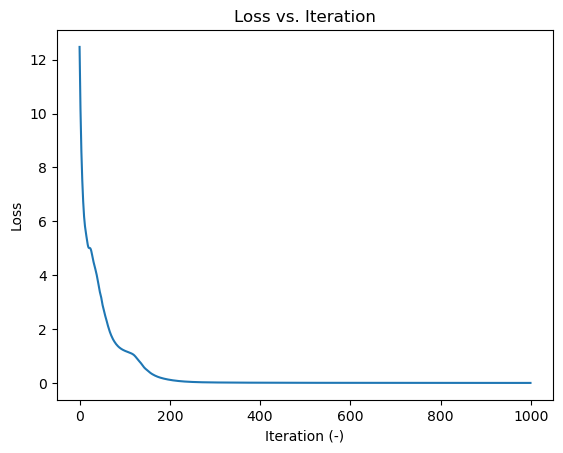

In [21]:
plt.figure()
plt.title("Loss vs. Iteration")
plt.plot(LOSS)
plt.xlabel("Iteration (-)")
plt.ylabel("Loss");

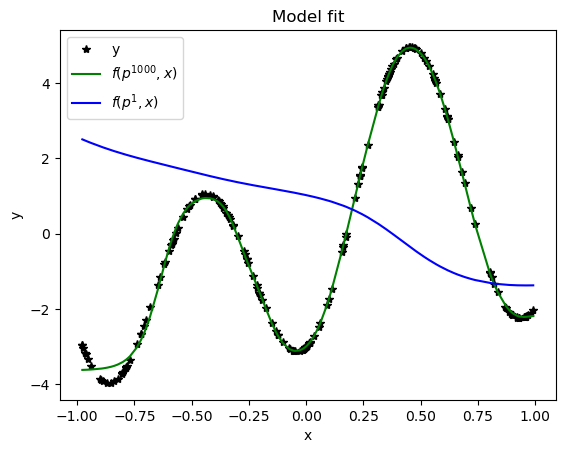

In [22]:
x_train_srt = jnp.sort(x_train, axis=0)
plt.figure()
plt.title("Model fit")
plt.plot(x_train, y_train, "k*", label="y")
plt.plot(x_train_srt, batched_nn(params, x_train_srt), "g", label=f"$f(p^{{{iters}}}, x)$")
plt.plot(x_train_srt, batched_nn(params_init, x_train_srt), "b", label="$f(p^{1}, x)$")
plt.xlabel("x")
plt.ylabel("y")
plt.legend();

In [23]:
x_train.shape, y_train.shape

((200, 1), (200, 1))

### Training with minibatches

Consider the same example as before, but with a larger dataset.

In [24]:
a = -1 # lower limit x
b = 1 # higher limit x
n_samples_long = 20_000 # data point
sigma_e = 0.1 # noise std
x_train = a + jr.uniform(key_x, shape=(n_samples_long, 1))*(b - a);
x_train = x_train.reshape(-1, 1)
y_train = f(x_train)

x_train.shape, y_train.shape

((20000, 1), (20000, 1))

We can minimize the loss function using stochastic gradient descent (SGD) instead of batch gradient descent. This means that we will compute the gradient of the loss function using only a *subset* of the data (called a minibatch) at each iteration.

In [25]:
# 2-hidden-layer version

nx = 1; ny = 1; nh = 16
params = {
  "W1": jr.normal(key_W1, shape=(nh, nx)),
  "b1": jr.normal(key_b1, shape=(nh,)),
  "W2": jr.normal(key_W2, shape=(nh, nh)),
  "b2": jr.normal(key_b2, shape=(nh,)),
  "W3": jr.normal(key_W3, shape=(ny, nh)),
  "b3": jr.normal(key_b3, shape=(ny,)),
}


def nn(p, x):
    h1 = jnp.tanh(p["W1"] @ x + p["b1"])
    h2 = jnp.tanh(p["W2"] @ h1 + p["b2"])
    y = p["W3"] @ h2 + p["b3"]
    return y

A basic implementation

In [26]:
batch_size = 32

batch_idx = jr.randint(jr.key(101),  shape=(batch_size,), minval=0, maxval=n_samples)
batch_idx

Array([ 66,  46, 113, 165,  64, 144,   9, 187,  78, 188,  37, 175,   3,
       150,  19,  96, 106, 113,  65,  80,  85, 134,   4,  44,  60,  56,
        92, 161, 164,  33, 109,  26], dtype=int32)

In [27]:
# select batch_size training samples
x_train[batch_idx].shape

(32, 1)

In [28]:
lr = 1e-2
iters = 1000

# Setup optimizer
optimizer = optax.adam(learning_rate=lr)
opt_state = optimizer.init(params)
key = jr.key(101) # for random batch generation

# Training loop
LOSS_MINIBATCH = []
for iter in range(iters):

    key, subkey = jr.split(key, 2)
    batch_idx = jr.randint(subkey,  shape=(batch_size,), minval=0, maxval=n_samples)

    loss_val, grads = loss_grad_fn(params, y_train[batch_idx], x_train[batch_idx])
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    LOSS_MINIBATCH.append(loss_val)

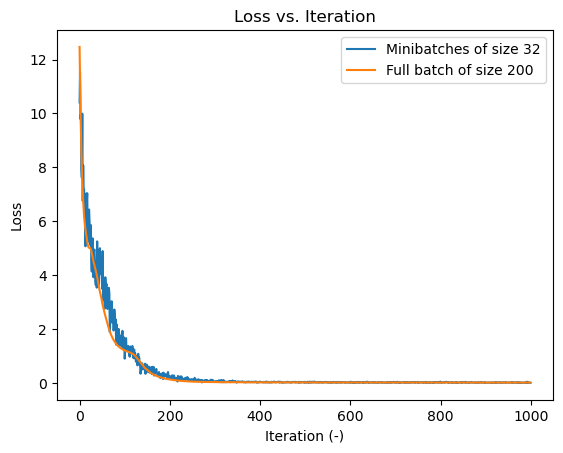

In [29]:
plt.figure()
plt.title("Loss vs. Iteration")
plt.plot(LOSS_MINIBATCH, label=f"Minibatches of size {batch_size}")
plt.plot(LOSS, label=f"Full batch of size {n_samples}")
plt.xlabel("Iteration (-)")
plt.ylabel("Loss");
plt.legend()